# (06) fit w/ grad, T=32

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>

repdocuce Gabors?

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
model_type = 'poisson'

cfg_vae, cfg_tr = default_configs('vH16', model_type, 'grad|lin')
cfg_vae['seq_len'] = 32
cfg_vae['n_iters'] = 1

cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 48.0

print(f"VAE:\n{cfg_vae}\n\nTrainer:\n{cfg_tr}")

VAE:
{'dataset': 'vH16', 'n_latents': 512, 'clamp_prior': -4, 'clamp_du': 10.0, 'clamp_u': 8.0, 'inf_type': 'grad', 
'dec_type': 'lin', 'init_dist': 'normal', 'init_scale': 0.0001, 'seq_len': 32, 'n_iters': 1, 'track_stats': True}

Trainer:
{'batch_size': 200, 'epochs': 300, 'optimizer_kws': {'weight_decay': 0.0}, 'grad_clip': 200, 'kl_beta': 48.0}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-32×1_b-1_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(48:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2025_02_09,22:57)

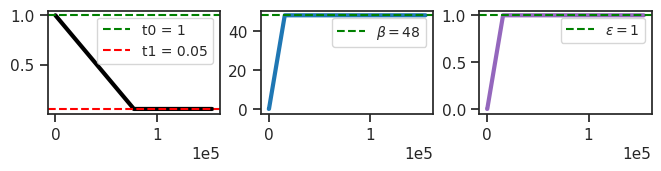

In [4]:
mod = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=1)

In [6]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr.shape # , tr.model.layer.log_gamma.exp()

(torch.Size([1, 512]), torch.Size([1]))

In [7]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 193.456761: 100%|████| 300/300 [3:47:09<00:00, 45.43s/it]


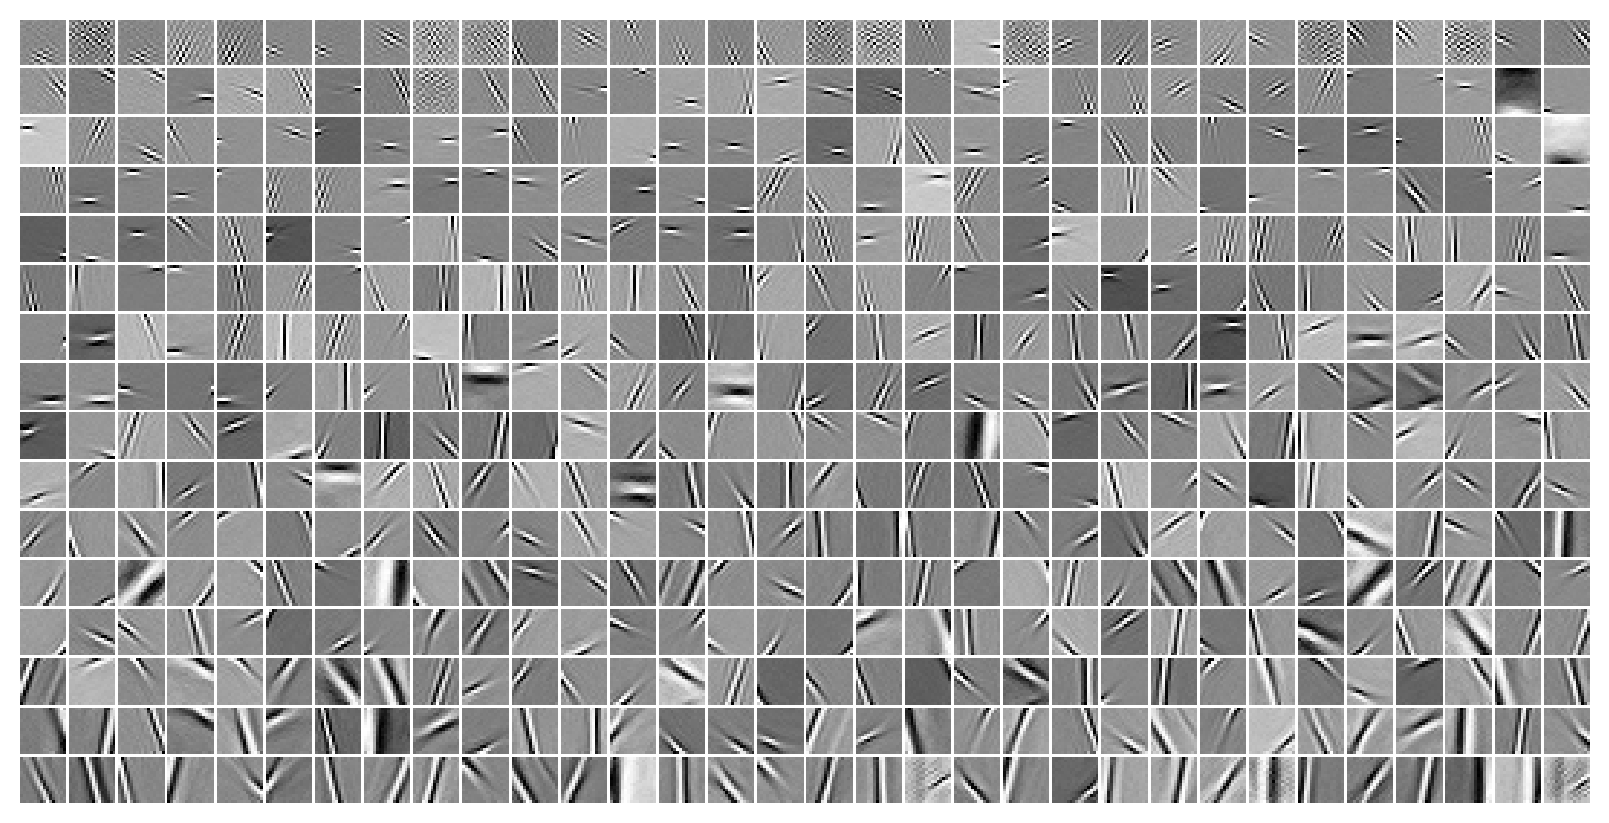

In [8]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

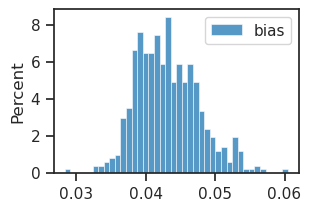

tensor([0.1433], device='cuda:0', grad_fn=<ExpBackward0>)

In [10]:
fig, ax = create_figure()

kws = dict(bins=40, stat='percent',  ax=ax)
sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', **kws)
# sns.histplot(tonp(tr.model.layer.log_lr.squeeze().exp()), label='lr', **kws)
ax.legend()
plt.show()

tr.model.layer.log_lr.exp()

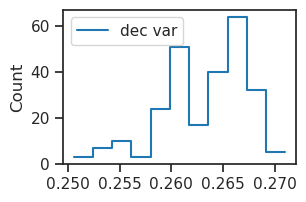

In [11]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()

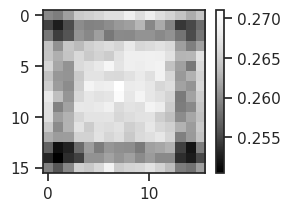

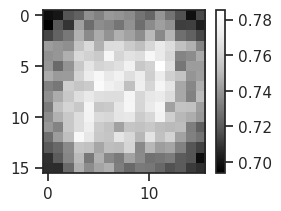

In [12]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar();

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar();

In [13]:
%%time

feeder = tr.get_feeder(next(iter(tr.dl_vld))[0])
output = tr.model.xtract_ftr(feeder, seq=range(1000), return_extras=True).stack()

print(list(output))

['loss_kl', 'loss_recon', 'posterior', 'u', 'v', 'recon', 'samples', 'conditional']

CPU times: user 1.95 s, sys: 212 ms, total: 2.17 s
Wall time: 2.17 s


[0.813396692276001,
 0.813104510307312,
 0.8130203485488892,
 0.813942551612854,
 0.8134324550628662]

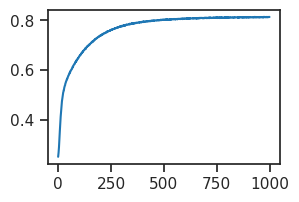

In [14]:
from analysis.sparse import sparse_score

t = 0
lifetime, population = [], []
for t in range(1000):
    life, popu, _ = sparse_score(output['samples'][:, t, :])
    lifetime.append(life.mean().item())
    population.append(popu.mean().item())


plt.plot(lifetime);
lifetime[-5:]

tensor([17.4464, 17.5888, 17.6310, 17.5259, 17.4957], device='cuda:0')

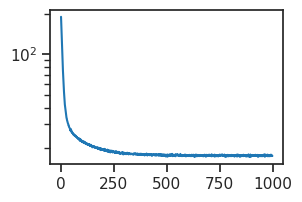

In [15]:
locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log');

mse.mean(0)[-5:]

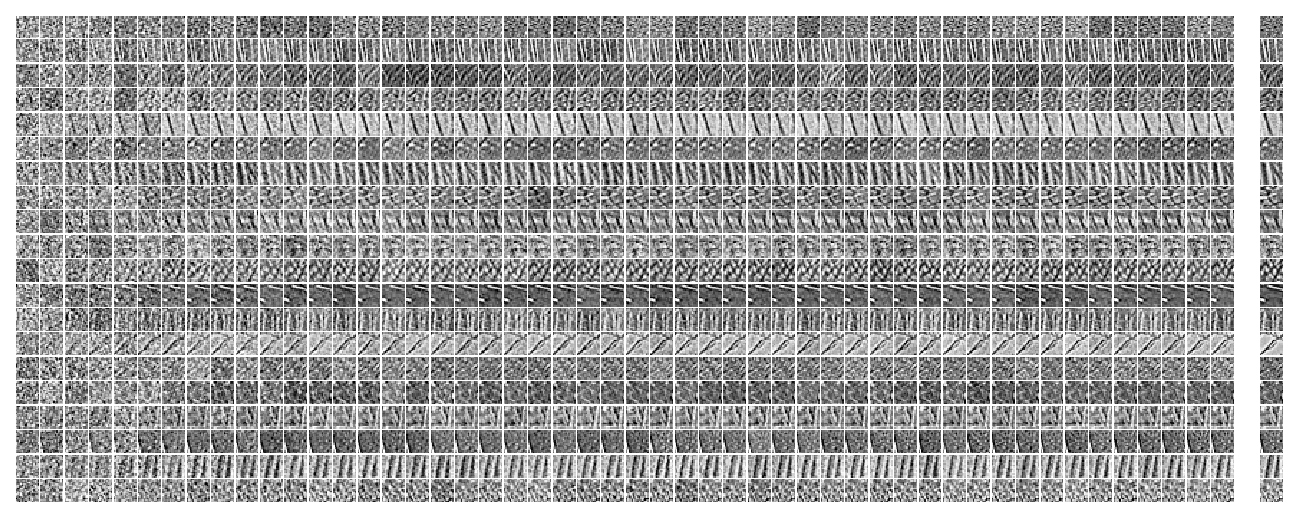

In [16]:
num = 20
n_timepoints = 50
x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

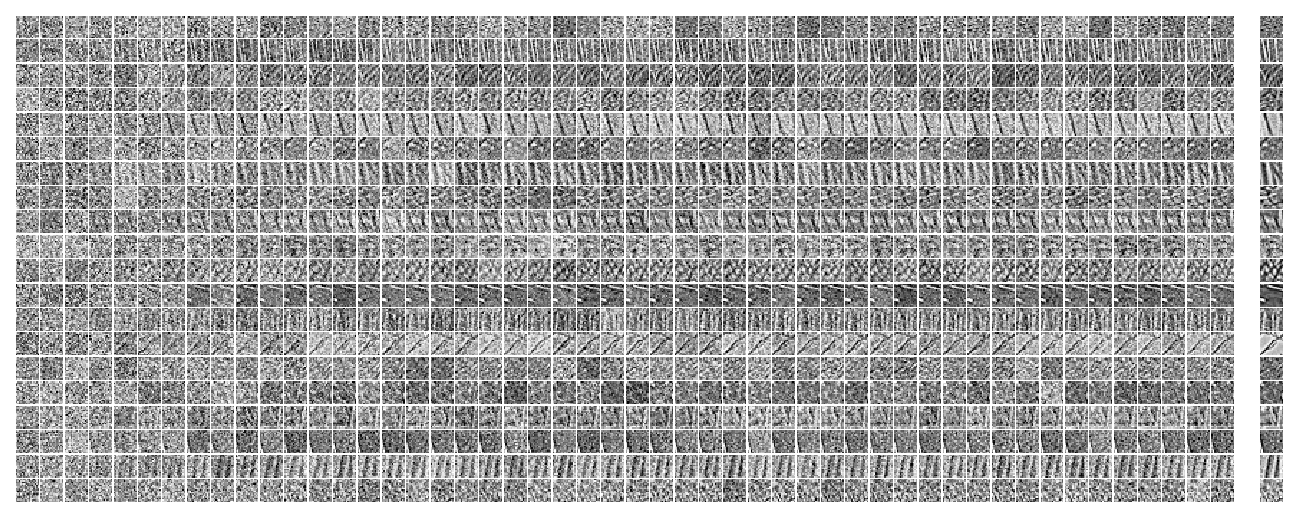

In [17]:
num = 20
n_timepoints = 50
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()
# .reshape(tr.model.cfg.shape)

_ = plot_weights(x2p, nrows=num)

tensor([0.2374, 0.2308, 0.2353, 0.2444, 0.2304], device='cuda:0')

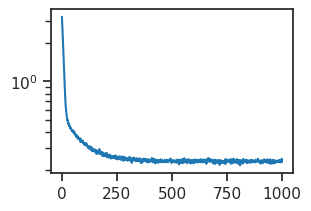

In [18]:
fig, ax = create_figure()

x2p = output['loss_kl'].sum(-1).mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([97.5454, 97.8123, 97.8869, 97.6923, 97.6390], device='cuda:0')

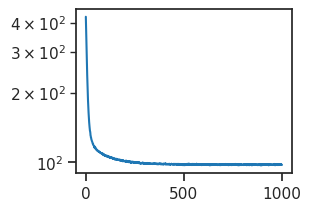

In [19]:
fig, ax = create_figure()

x2p = output['loss_recon'].mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

tensor([17.4464, 17.5888, 17.6310, 17.5259, 17.4957], device='cuda:0')

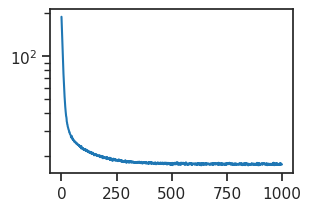

In [20]:
fig, ax = create_figure()

x2p = mse.mean(0)
plot(x2p)
ax.set(yscale='log');

x2p[-5:]

In [21]:
print(tr.model.layer)

PoissonLayer(input_dim=256,latent_dim=512, beta_inner=1, temp=0.05)